# NDVI Anomaly Detection with openEO

This notebook demonstrates the detection of **NDVI anomalies** using Sentinel-2
imagery with the openEO API.

## Overview

In this notebook, we will:
1. Connect to an openEO backend service
2. Define an agricultural area of interest with multi-year Sentinel-2 coverage
3. Load several years of Sentinel-2 L2A imagery for a given target month
4. Compute the per-pixel NDVI anomaly (current month vs. same-month baseline)
5. Visualize and export the result as a reusable openEO process

## What is an NDVI anomaly?

The **Normalized Difference Vegetation Index** (NDVI = (NIR - Red) / (NIR + Red))
measures vegetation greenness. An *anomaly* compares the NDVI of a target month in
the current year against the average NDVI for the **same month** over the previous
*N* years (the baseline). Negative values mean less vegetation than usual
(e.g. drought stress, crop loss), positive values mean more vegetation than usual.

This is a conversion of the Sentinel Hub
[NDVI Anomaly Detection](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi_anomaly_detection/)
evalscript by Jean-Baptiste Pleynet, originally designed to drive crop-loss
insurance triggers.

### How the conversion maps to openEO

The original evalscript relies on Sentinel Hub `ORBIT` mosaicking and a
`preProcessScenes` step that keeps only orbits from the **same month** across the
last *N* years, then averages NDVI per year inside `evaluatePixel`. We reproduce
that temporal logic with standard openEO processes:

| Original (evalscript) | openEO conversion |
| --- | --- |
| `mosaicking: "ORBIT"` + `preProcessScenes` month/year filter | `aggregate_temporal` with one interval per past year, same month |
| Per-year NDVI averaging in `evaluatePixel` | `reduce_dimension("t", "mean")` |
| Braaten-Cohen-Yang cloud detector | Scene Classification Layer (SCL) mask + `eo:cloud_cover` filter |
| `clamp(current - past, ±0.7)` | `clip(current - past, -0.7, 0.7)` |
| Red→white→green RGB interpolation | single-band anomaly + `RdYlGn` colormap at visualization time |


## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi_anomaly_detection/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and
visualization.


In [1]:
import datetime

import ipynbname
import shapely
import rioxarray
import matplotlib.pyplot as plt
from openeo.processes import clip

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend. We use the **Copernicus Data Space Ecosystem (CDSE)** because the
anomaly requires several years of Sentinel-2 archive.


In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = ipynbname.name()

# Initialize parameter manager
param_manager = ParameterManager('ndvi_anomaly_detection.params.py')

# Display available options using the built-in helper
param_manager.print_options("NDVI anomaly detection algorithm")

Available parameter sets for NDVI anomaly detection algorithm:
  1. cropland_plain_croatia: Cropland Plain, Istria Coast, Croatia
  2. po_valley_cropland_italy: Po Valley Cropland, Italy
  3. leipzig_drought_2018_germany: South of Leipzig, Germany (2018 drought, August peak)
  4. leipzig_drought_2018_october_germany: South of Leipzig, Germany (2018 drought, October end)

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# Connect using a parameter set for a specified location on the CDSE endpoint.
# CDSE is required here because the multi-year Sentinel-2 archive is needed.
connection, current_params = param_manager.quick_connect(
    param_set="po_valley_cropland_italy",
    endpoint="copernicus_dataspace",
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: po_valley_cropland_italy
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Po Valley Cropland, Italy
🔄 Parameters mapped for endpoint copernicus_dataspace:


## Derive the Multi-Year Look-Back Window

The `time` parameter defines the **target month of the current year**. From it and
`nb_past_years` we derive:
- the full temporal extent to load (target month of the earliest baseline year
  through the current target month), and
- one temporal interval per past year covering the same month (the baseline windows).


In [4]:
# Algorithm configuration (resolved from the selected parameter set).
# The temporal windows are computed in Python and baked into the process graph,
# so `time` and `nb_past_years` are build-time configuration; `bounding_box` and
# `cloud_cover` remain the runtime knobs of the exported UDP.
time = current_params["time"].default              # e.g. ["2022-07-01", "2022-08-01"]
nb_past_years = current_params["nb_past_years"].default
anomaly_clamp = current_params["anomaly_clamp"].default
ndvi_min = current_params["ndvi_min"].default

_start = datetime.date.fromisoformat(time[0])
_end = datetime.date.fromisoformat(time[1])
current_year = _start.year

# Full extent to load: same month, from the earliest baseline year to the current year.
load_extent = [
    _start.replace(year=current_year - nb_past_years).isoformat(),
    time[1],
]

# One interval per past year covering the same month (the baseline windows).
past_intervals = [
    [
        _start.replace(year=current_year - i).isoformat(),
        _end.replace(year=_end.year - i).isoformat(),
    ]
    for i in range(1, nb_past_years + 1)
]

print(f"Target month (current year): {time}")
print(f"Loading extent:              {load_extent}")
print(f"Baseline intervals:          {past_intervals}")

Target month (current year): ['2022-07-01', '2022-08-01']
Loading extent:              ['2019-07-01', '2022-08-01']
Baseline intervals:          [['2021-07-01', '2021-08-01'], ['2020-07-01', '2020-08-01'], ['2019-07-01', '2019-08-01']]


## Load Sentinel-2 Data

Load Sentinel-2 L2A (atmospherically corrected) data. We need:

- **B04** (664.6 nm): Red band
- **B08** (832.8 nm): NIR band
- **SCL**: Scene Classification Layer, used for cloud/shadow masking

We also apply an `eo:cloud_cover` scene-level filter and clip to the area of
interest.


In [5]:
# Load Sentinel-2 data across the multi-year window.
s2cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=load_extent,
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
)

# Avoid extra data outside the spatial extent
bbox = current_params["bounding_box"].default
s2cube = s2cube.mask_polygon(
    shapely.geometry.box(
        minx=bbox["west"],
        miny=bbox["south"],
        maxx=bbox["east"],
        maxy=bbox["north"],
    )
)

print("✅ Sentinel-2 data loaded successfully!")

✅ Sentinel-2 data loaded successfully!


## Cloud and Shadow Masking (SCL)

The original evalscript reimplements the Braaten-Cohen-Yang cloud detector because
Sentinel Hub `ORBIT` mosaicking hands it raw multi-temporal samples. In openEO we
use the **Scene Classification Layer (SCL)** instead, which is the idiomatic
approach. We drop pixels classified as cloud shadow (3), cloud medium probability
(8), cloud high probability (9), thin cirrus (10), and snow/ice (11).


In [6]:
# Build a mask from the SCL band: True where we want to discard the pixel.
# Find the first band whose name starts with "SCL" (case-insensitive); the exact
# band name varies by collection/backend (e.g. "SCL" on CDSE, "SCL_20m" elsewhere).
scl_band = next(b for b in s2cube.metadata.band_names if b.lower().startswith("scl"))
scl = s2cube.band(scl_band)
invalid = (scl == 3) | (scl == 8) | (scl == 9) | (scl == 10) | (scl == 11)

# mask() removes pixels where the mask is non-zero (True).
s2_masked = s2cube.mask(invalid)

## Compute NDVI

NDVI is `normalized_difference(B08, B04)`. Because it is a normalized ratio, it is
**invariant to the band reflectance scale**, so no `reflectance_scale` parameter is
required here (unlike the LAI/Cab biophysical algorithms). Values at or below
`ndvi_min` are treated as invalid, mirroring the original `ndviMinValue` guard.


In [7]:
# NDVI = (B08 - B04) / (B08 + B04), built with the normalized_difference process.
# Resolve band names by prefix since backends may rename them (e.g. "B08_10m").
nir_band = next(b for b in s2_masked.metadata.band_names if b.lower().startswith("b08"))
red_band = next(b for b in s2_masked.metadata.band_names if b.lower().startswith("b04"))
nir = s2_masked.band(nir_band) / current_params["reflectance_scale"]  # scale to reflectance
red = s2_masked.band(red_band) / current_params["reflectance_scale"]  # scale to reflectance
ndvi = nir.normalized_difference(red)

# Drop physically implausible NDVI values (original `ndviMinValue` guard).
ndvi = ndvi.mask(ndvi < ndvi_min)

## NDVI Anomaly = Current − Baseline

We build two cubes and subtract them:

- **current**: the NDVI averaged over the target month of the current year.
- **baseline**: the same month aggregated to a per-year mean over the past
  `nb_past_years` years (`aggregate_temporal`), then averaged across those years
  (`reduce_dimension`). Averaging per year first gives each year equal weight,
  matching the original `calculatePastIndexesAverage`.

The anomaly is then clamped to `±anomaly_clamp` (the original `pixelEvalMaxValue`).

> **Note on observation guards:** the original requires a minimum number of valid
> observations (`currentIndexesMinValuesNumber=1`, `pastIndexesMinValuesNumber=3`).
> Here the mean over cloud-masked data naturally yields no-data where observations
> are missing; a stricter `count`-based mask could be added as a refinement.


In [8]:
# Current-year monthly mean NDVI
current_ndvi = ndvi.filter_temporal(time).reduce_dimension(dimension="t", reducer="mean")

# Baseline: per-year monthly means over the past years, then averaged across years
past_yearly = ndvi.aggregate_temporal(intervals=past_intervals, reducer="mean")
past_baseline = past_yearly.reduce_dimension(dimension="t", reducer="mean")

# Anomaly, clamped to the symmetric range used by the original script
anomaly = current_ndvi - past_baseline
anomaly = anomaly.apply(lambda x: clip(x, -anomaly_clamp, anomaly_clamp))

## Apply and Export

Save the single-band anomaly as a GeoTIFF.


In [9]:
anomaly_result = anomaly.save_result("GTiff")

## Download and Visualize Results

Download the anomaly for the selected area and display it with a diverging
red→white→green colormap, reproducing the original color scheme: **red** = vegetation
loss, **white** = no change, **green** = vegetation gain.


In [10]:
# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialize them with the current parameter set's defaults before download.
# The underlying parameterized graph is preserved for the UDP export cell below.
filename = f"{_algorithm_id}_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tif"

resolved = param_manager.resolve(anomaly_result, current_params)
resolved.download(filename)

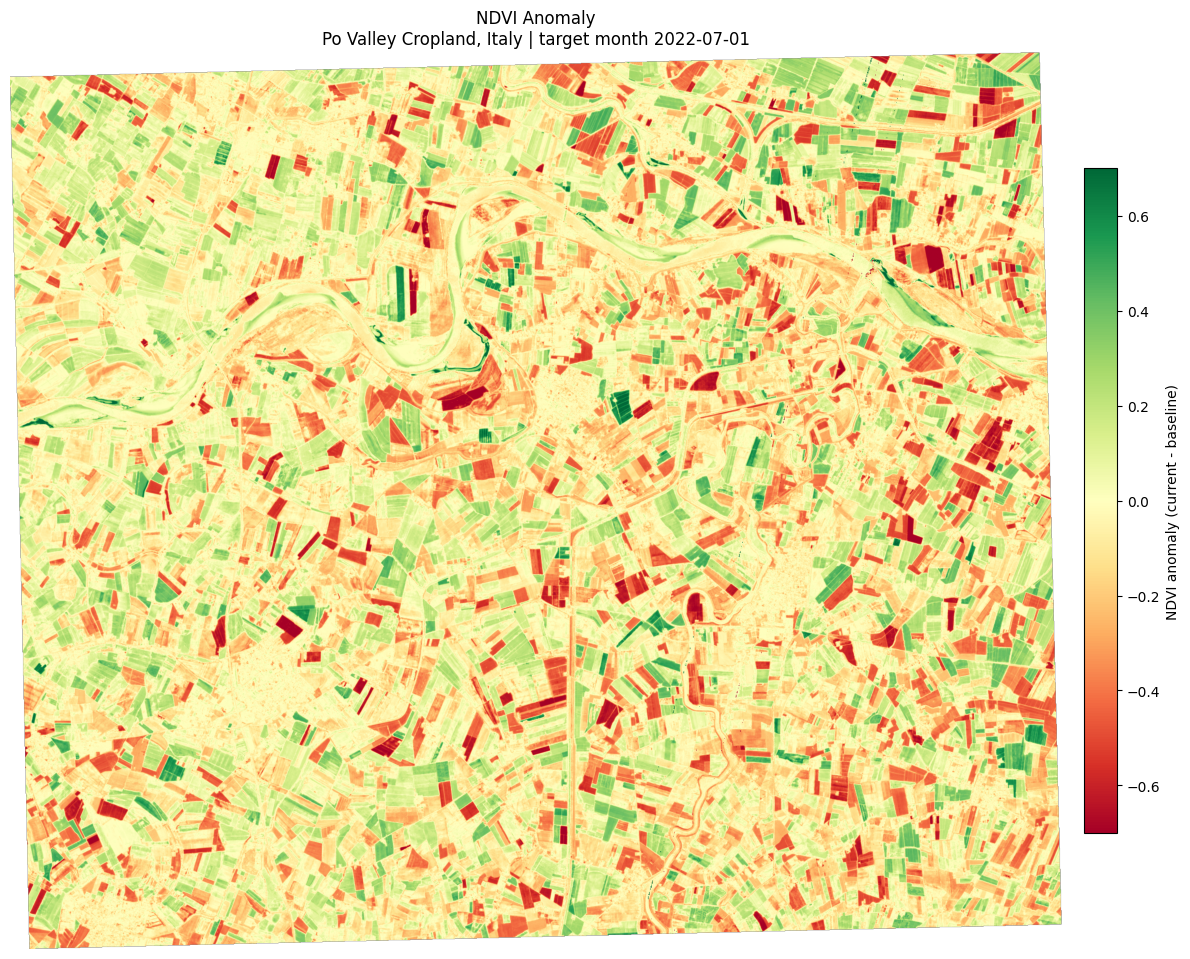

In [11]:
# Open the result. Some backends (e.g. titiler-openeo) return the single
# anomaly band duplicated across bands; CDSE returns a single band. Select the
# first data band so the plot works regardless of backend.
ds = rioxarray.open_rasterio(filename)
if "band" in ds.dims:
    ds = ds.isel(band=0)
ds = ds.squeeze()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(
    ds,
    extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
    cmap="RdYlGn",
    vmin=-anomaly_clamp,
    vmax=anomaly_clamp,
)
plt.colorbar(im, ax=ax, label="NDVI anomaly (current - baseline)", fraction=0.03, pad=0.02)
ax.set_title(
    f"NDVI Anomaly\n{current_params['location_name']} | target month {time[0]}",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide

### NDVI anomaly results

**Red pixels (negative anomaly)**
- Less vegetation than the multi-year baseline for this month
- Drought stress, crop failure, early senescence, harvested/cleared land

**White pixels (near zero)**
- Vegetation greenness in line with the historical baseline

**Green pixels (positive anomaly)**
- More vegetation than usual
- Favourable growing conditions, irrigation, land-use change towards vegetation

Values are clamped to ±0.7. No-data areas (persistent cloud or insufficient
observations) are transparent.


In [12]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "algorithm_registration").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

StopIteration: 

In [ ]:
# Export the process graph for reuse
import json

process_graph = {
    "process_graph": anomaly_result.flat_graph(),
    "parameters": [
        current_params["time"].to_dict(),
        current_params["bounding_box"].to_dict(),
        current_params["cloud_cover"].to_dict(),
        current_params["nb_past_years"].to_dict(),
        current_params["anomaly_clamp"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "NDVI anomaly detection from multi-year Sentinel-2 imagery using openEO.",
    "description": (
        "Computes the per-pixel NDVI anomaly from Sentinel-2 L2A imagery by comparing "
        "the current month's mean NDVI against the same-month average over the previous "
        "N years. Negative values indicate vegetation loss (e.g. drought or crop loss), "
        "positive values indicate vegetation gain. Converted from the Sentinel Hub "
        "NDVI Anomaly Detection evalscript."
    ),
}

# Save the process graph
with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

In [ ]:
# Export necessary metadata to register the process graph in APEx Algorithm Catalogue
if "_algorithm_id" not in globals():
    _algorithm_id = "ndvi_anomaly_detection"

_repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists())
_nb_href = f"{(Path.cwd() / 'ndvi_anomaly_detection.ipynb').relative_to(_repo_root)}"
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"

_records_dir.mkdir(parents=True, exist_ok=True)
# Notebook metadata
metadata = {
    "id": _algorithm_id,
    "title": "NDVI Anomaly Detection",
    "preview_title": "NDVI Anomaly Detection",
    "description": (
        "Computes the per-pixel NDVI anomaly from Sentinel-2 L2A imagery by comparing "
        "the current month's mean NDVI against the same-month average over the previous "
        "N years. Negative values indicate vegetation loss (e.g. drought or crop loss), "
        "positive values indicate vegetation gain."
    ),
    "keywords": ["Agriculture", "Vegetation", "NDVI", "Anomaly", "Drought", "Sentinel-2"],
    "themes": ["VEGETATION", "AGRICULTURE", "REMOTE SENSING", "Sentinel-2 MSI"],
    "created": "2026-06-19T00:00:00Z",
    "updated": "2026-06-19T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL2_L2A",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi_anomaly_detection/",
        "authors": ["Jean-Baptiste Pleynet"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": None,
    },
}

# Save the catalogue record
with open(f"{_records_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Catalogue record exported to {_records_dir}/{_algorithm_id}.json")

## References and Attribution

**Original Script:** [NDVI Anomaly Detection](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi_anomaly_detection/)

**Author:** Jean-Baptiste Pleynet

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### openEO Conversion
- **Conversion Date**: 19 June 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0


## Conclusion

This notebook demonstrates the conversion of the NDVI Anomaly Detection algorithm to
an openEO User-Defined Process. The implementation:

✅ **Reproduces the temporal logic** of the original `ORBIT` mosaicking and
`preProcessScenes` month/year filtering using `aggregate_temporal` and
`reduce_dimension`.

✅ **Uses idiomatic openEO cloud masking** via the Scene Classification Layer
instead of the original Braaten-Cohen-Yang detector.

✅ **Produces a reusable single-band anomaly** clamped to ±0.7, with the
red→white→green color scheme applied at visualization time.

✅ **Follows openEO standards** with an exported, parameterized process graph and
catalogue metadata.

### Key conversion notes
- NDVI is reflectance-scale invariant, so no `reflectance_scale` parameter is needed.
- The temporal windows are computed in Python and baked into the graph; `bounding_box`
  and `cloud_cover` are the runtime knobs.
- The strict minimum-observation guards of the original are simplified to mean-over-
  masked behaviour.
